In [ ]:
pip install pyyaml


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import yaml
import os

folder_path = r"E:\odis"
all_balls = []
inning_labels = ['1st innings', '2nd innings', '3rd innings', '4th innings']

files = [f for f in os.listdir(folder_path) if f.endswith('.yaml')]
total = len(files)

for i, filename in enumerate(files):
    if i % 500 == 0:
        print(f"Processing {i}/{total} files...")

    filepath = os.path.join(folder_path, filename)
    with open(filepath, encoding='utf-8') as f:
        match = yaml.safe_load(f)

    info = match.get('info', {})
    match_id = filename.replace('.yaml', '')
    date = info.get('dates', [''])[0]
    venue = info.get('venue', '')
    city = info.get('city', '')
    teams = info.get('teams', ['', ''])
    season = info.get('season', '')
    gender = info.get('gender', '')
    match_type = info.get('match_type', '')
    toss_winner = info.get('toss', {}).get('winner', '')
    toss_decision = info.get('toss', {}).get('decision', '')
    outcome_winner = info.get('outcome', {}).get('winner', '')

    innings_data = match.get('innings', [])

    for inning_num, inning_label in enumerate(inning_labels):
        inning = None
        for item in innings_data:
            if inning_label in item:
                inning = item[inning_label]
                break
        if inning is None:
            continue

        batting_team = inning.get('team', '')
        bowling_team = teams[1] if batting_team == teams[0] else teams[0]
        target_runs = inning.get('target', {}).get('runs', None) if isinstance(inning.get('target'), dict) else None

        for delivery_dict in inning.get('deliveries', []):
            for ball_key, delivery in delivery_dict.items():
                parts = str(ball_key).split('.')
                over_num = int(parts[0])
                ball_num = int(parts[1]) if len(parts) > 1 else 0

                extras = delivery.get('extras', {}) or {}

                # Handle both dict and list formats for wicket
                raw_wicket = delivery.get('wicket', None)
                if isinstance(raw_wicket, dict):
                    wicket = raw_wicket
                    fielders = wicket.get('fielders', [])
                    # fielders can be list of strings or list of dicts
                    if fielders and isinstance(fielders[0], dict):
                        fielder_name = fielders[0].get('name', '')
                    else:
                        fielder_name = fielders[0] if fielders else ''
                    dismissal_kind = wicket.get('kind', '')
                    player_out = wicket.get('player_out', '')
                    is_wicket = 1
                elif isinstance(raw_wicket, list) and raw_wicket:
                    wicket = raw_wicket[0]
                    fielders = wicket.get('fielders', [])
                    if fielders and isinstance(fielders[0], dict):
                        fielder_name = fielders[0].get('name', '')
                    else:
                        fielder_name = fielders[0] if fielders else ''
                    dismissal_kind = wicket.get('kind', '')
                    player_out = wicket.get('player_out', '')
                    is_wicket = 1
                else:
                    fielder_name = ''
                    dismissal_kind = ''
                    player_out = ''
                    is_wicket = 0

                row = {
                    'match_id'       : match_id,
                    'date'           : date,
                    'season'         : season,
                    'venue'          : venue,
                    'city'           : city,
                    'gender'         : gender,
                    'match_type'     : match_type,
                    'team1'          : teams[0],
                    'team2'          : teams[1],
                    'toss_winner'    : toss_winner,
                    'toss_decision'  : toss_decision,
                    'outcome_winner' : outcome_winner,
                    'inning'         : inning_num + 1,
                    'batting_team'   : batting_team,
                    'bowling_team'   : bowling_team,
                    'target_runs'    : target_runs,
                    'over'           : over_num,
                    'ball'           : ball_num,
                    'batter'         : delivery.get('batsman', ''),
                    'non_striker'    : delivery.get('non_striker', ''),
                    'bowler'         : delivery.get('bowler', ''),
                    'runs_batter'    : delivery.get('runs', {}).get('batsman', 0),
                    'runs_extras'    : delivery.get('runs', {}).get('extras', 0),
                    'runs_total'     : delivery.get('runs', {}).get('total', 0),
                    'wides'          : extras.get('wides', 0),
                    'noballs'        : extras.get('noballs', 0),
                    'legbyes'        : extras.get('legbyes', 0),
                    'byes'           : extras.get('byes', 0),
                    'wicket'         : is_wicket,
                    'dismissal_kind' : dismissal_kind,
                    'player_out'     : player_out,
                    'fielder'        : fielder_name,
                    'fielder_sub'    : False,
                }
                all_balls.append(row)

df = pd.DataFrame(all_balls)
df.to_csv(r"E:\odi_international.csv", index=False)
print(f"Done! Total deliveries: {len(df)}")
print(df.head())

Processing 0/3136 files...
Processing 500/3136 files...
Processing 1000/3136 files...
Processing 1500/3136 files...
Processing 2000/3136 files...
Processing 2500/3136 files...
Processing 3000/3136 files...
Done! Total deliveries: 1659349
  match_id        date season                                   venue  \
0  1000887  2017-01-13         Brisbane Cricket Ground, Woolloongabba   
1  1000887  2017-01-13         Brisbane Cricket Ground, Woolloongabba   
2  1000887  2017-01-13         Brisbane Cricket Ground, Woolloongabba   
3  1000887  2017-01-13         Brisbane Cricket Ground, Woolloongabba   
4  1000887  2017-01-13         Brisbane Cricket Ground, Woolloongabba   

       city gender match_type      team1     team2 toss_winner  ...  \
0  Brisbane   male        ODI  Australia  Pakistan   Australia  ...   
1  Brisbane   male        ODI  Australia  Pakistan   Australia  ...   
2  Brisbane   male        ODI  Australia  Pakistan   Australia  ...   
3  Brisbane   male        ODI  Australi

In [ ]:
import pandas as pd

df = pd.read_csv(r"E:\odi_international.csv", low_memory=False)

# Confirm Australia exists
aus_teams = [t for t in df['batting_team'].unique() if 'ustr' in t]
print("Teams:", aus_teams)

# Check our batters
aus_batters = ['MR Marsh', 'M Labuschagne', 'JP Inglis', 'C Green', 
               'L Scott', 'TM Head', 'AT Carey', 'MT Renshaw', 'C Connolly']

aus_df = df[df['batter'].isin(aus_batters) & (df['batting_team'] == 'Australia')].copy()

print(f"\nTotal deliveries to AUS batters: {len(aus_df)}")
print("\nDeliveries per batter:")
print(aus_df['batter'].value_counts())

Teams: ['Australia']

Total deliveries to AUS batters: 13176

Deliveries per batter:
batter
MR Marsh         3314
TM Head          2860
AT Carey         2560
M Labuschagne    2263
C Green           985
JP Inglis         833
MT Renshaw        223
C Connolly        138
Name: count, dtype: int64


In [1]:
print("R kernel is working!")

[1] "R kernel is working!"


In [2]:
library(tidyverse)

df <- read_csv("E:/odi_international.csv")
glimpse(df)


ERROR: Error in library(tidyverse): there is no package called 'tidyverse'


In [3]:
install.packages("tidyverse")


Installing package into 'C:/Users/User/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)

also installing the dependencies 'sys', 'bit', 'ps', 'sass', 'cachem', 'farver', 'labeling', 'RColorBrewer', 'viridisLite', 'rappdirs', 'rematch', 'askpass', 'bit64', 'prettyunits', 'otel', 'processx', 'highr', 'xfun', 'yaml', 'bslib', 'fontawesome', 'jquerylib', 'tinytex', 'backports', 'generics', 'memoise', 'blob', 'DBI', 'R6', 'tidyselect', 'withr', 'data.table', 'gtable', 'isoband', 'S7', 'scales', 'gargle', 'cellranger', 'curl', 'ids', 'rematch2', 'cpp11', 'pkgconfig', 'mime', 'openssl', 'timechange', 'systemfonts', 'textshaping', 'clipr', 'vroom', 'tzdb', 'progress', 'callr', 'fs', 'knitr', 'rmarkdown', 'selectr', 'stringi', 'broom', 'conflicted', 'dbplyr', 'dplyr', 'dtplyr', 'forcats', 'ggplot2', 'googledrive', 'googlesheets4', 'haven', 'hms', 'httr', 'lubridate', 'magrittr', 'modelr', 'purrr', 'ragg', 'readr', 'readxl', 'reprex', 'rstudioapi', 'rvest', 'stringr', 'tibble', 'tidyr'

package 'sys' successfully unpacked and MD5 sums checked
package 'bit' successfully unpacked and MD5 sums checked
package 'ps' successfully unpacked and MD5 sums checked
package 'sass' successfully unpacked and MD5 sums checked
package 'cachem' successfully unpacked and MD5 sums checked
package 'farver' successfully unpacked and MD5 sums checked
package 'labeling' successfully unpacked and MD5 sums checked
package 'RColorBrewer' successfully unpacked and MD5 sums checked
package 'viridisLite' successfully unpacked and MD5 sums checked
package 'rappdirs' successfully unpacked and MD5 sums checked
package 'rematch' successfully unpacked and MD5 sums checked
package 'askpass' successfully unpacked and MD5 sums checked
package 'bit64' successfully unpacked and MD5 sums checked
package 'prettyunits' successfully unpacked and MD5 sums checked
package 'otel' successfully unpacked and MD5 sums checked
package 'processx' successfully unpacked and MD5 sums checked
package 'highr' successfully un

In [1]:
library(tidyverse)

df <- read_csv("E:/odi_international.csv")
glimpse(df)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 1659349 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (17): venue, city, gender, match_type, team1, team2, toss_winner, toss_...
dbl  (12): match_id, inning, over, ball, runs_batter, runs_extras, runs_tota...
lgl   (3): season, target_runs, fielder_sub
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to

Rows: 1,659,349
Columns: 33
$ match_id       <dbl> 1000887, 1000887, 1000887, 1000887, 1000887, 1000887, 1…
$ date           <date> 2017-01-13, 2017-01-13, 2017-01-13, 2017-01-13, 2017-0…
$ season         <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ venue          <chr> "Brisbane Cricket Ground, Woolloongabba", "Brisbane Cri…
$ city           <chr> "Brisbane", "Brisbane", "Brisbane", "Brisbane", "Brisba…
$ gender         <chr> "male", "male", "male", "male", "male", "male", "male",…
$ match_type     <chr> "ODI", "ODI", "ODI", "ODI", "ODI", "ODI", "ODI", "ODI",…
$ team1          <chr> "Australia", "Australia", "Australia", "Australia", "Au…
$ team2          <chr> "Pakistan", "Pakistan", "Pakistan", "Pakistan", "Pakist…
$ toss_winner    <chr> "Australia", "Australia", "Australia", "Australia", "Au…
$ toss_decision  <chr> "bat", "bat", "bat", "bat", "bat", "bat", "bat", "bat",…
$ outcome_winner <chr> "Australia", "Australia", "Australia", "Australia", "Au…
$ inning    

In [2]:
aus_batters <- c("MR Marsh", "TM Head", "AT Carey", "M Labuschagne", 
                 "C Green", "JP Inglis", "MT Renshaw", "C Connolly")

aus_df <- df %>%
  filter(batting_team == "Australia", batter %in% aus_batters)

# Check delivery count per batter
aus_df %>%
  count(batter, sort = TRUE)
  

batter,n
<chr>,<int>
MR Marsh,3314
TM Head,2860
AT Carey,2560
M Labuschagne,2263
C Green,985
JP Inglis,833
MT Renshaw,223
C Connolly,138


In [3]:
aus_df %>%
  group_by(batter) %>%
  summarise(
    balls        = n(),
    runs         = sum(runs_batter),
    dismissals   = sum(wicket),
    avg          = round(runs / dismissals, 2),
    sr           = round(runs / balls * 100, 2),
    dot_pct      = round(mean(runs_batter == 0) * 100, 2),
    boundary_pct = round(mean(runs_batter %in% c(4, 6)) * 100, 2)
  ) %>%
  arrange(desc(balls))

batter,balls,runs,dismissals,avg,sr,dot_pct,boundary_pct
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MR Marsh,3314,3066,79,38.81,92.52,53.20,11.59
TM Head,2860,2948,68,43.35,103.08,50.98,14.41
AT Carey,2560,2264,68,33.29,88.44,49.45,9.41
M Labuschagne,2263,1862,55,33.85,82.28,47.64,7.20
C Green,985,835,19,43.95,84.77,52.39,8.83
JP Inglis,833,830,27,30.74,99.64,50.42,12.61
MT Renshaw,223,211,4,52.75,94.62,38.12,6.73
C Connolly,138,94,4,23.50,68.12,55.80,5.80


In [4]:
aus_df %>%
  mutate(phase = case_when(
    over <= 9  ~ "Powerplay",
    over <= 39 ~ "Middle",
    TRUE       ~ "Death"
  )) %>%
  group_by(batter, phase) %>%
  summarise(
    balls    = n(),
    runs     = sum(runs_batter),
    sr       = round(runs / balls * 100, 2),
    dot_pct  = round(mean(runs_batter == 0) * 100, 2),
    wickets  = sum(wicket),
    .groups  = "drop"
  ) %>%
  arrange(batter, phase)

batter,phase,balls,runs,sr,dot_pct,wickets
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
AT Carey,Death,590,676,114.58,34.07,25
AT Carey,Middle,1741,1428,82.02,51.92,37
AT Carey,Powerplay,229,160,69.87,70.31,6
C Connolly,Death,39,39,100.00,46.15,1
C Connolly,Middle,72,52,72.22,48.61,1
C Connolly,Powerplay,27,3,11.11,88.89,2
C Green,Death,169,222,131.36,37.87,4
C Green,Middle,748,564,75.40,54.28,14
C Green,Powerplay,68,49,72.06,67.65,1


In [5]:
aus_df %>%
  filter(wicket == 1) %>%
  group_by(batter, dismissal_kind) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(batter) %>%
  mutate(pct = round(n / sum(n) * 100, 1)) %>%
  arrange(batter, desc(n))

batter,dismissal_kind,n,pct
<chr>,<chr>,<int>,<dbl>
AT Carey,caught,39,57.4
AT Carey,bowled,11,16.2
AT Carey,lbw,8,11.8
AT Carey,run out,7,10.3
AT Carey,stumped,3,4.4
C Connolly,caught,2,50.0
C Connolly,lbw,1,25.0
C Connolly,retired hurt,1,25.0
C Green,caught,8,42.1


In [7]:
aus_df %>%
  arrange(desc(date)) %>%
  group_by(batter) %>%
  mutate(match_rank = dense_rank(desc(date))) %>%
  filter(match_rank <= 15) %>%
  group_by(batter) %>%
  summarise(
    matches   = n_distinct(match_id),
    runs      = sum(runs_batter),
    balls     = n(),
    sr        = round(runs / balls * 100, 2),
    dismissals = sum(wicket),
    avg       = round(runs / dismissals, 2),
    .groups   = "drop"
  ) %>%
  arrange(desc(runs))
  

batter,matches,runs,balls,sr,dismissals,avg
<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
TM Head,15,692,606,114.19,14,49.43
MR Marsh,15,663,739,89.72,13,51.00
JP Inglis,15,528,509,103.73,12,44.00
C Green,15,515,611,84.29,11,46.82
AT Carey,15,461,487,94.66,14,32.93
M Labuschagne,15,304,404,75.25,13,23.38
MT Renshaw,5,211,223,94.62,4,52.75
C Connolly,5,94,138,68.12,4,23.50


In [8]:
aus_df %>%
  filter(batter == "TM Head", wicket == 1) %>%
  arrange(desc(date)) %>%
  slice_head(n = 15) %>%
  mutate(phase = case_when(
    over <= 9  ~ "Powerplay",
    over <= 39 ~ "Middle",
    TRUE       ~ "Death"
  )) %>%
  select(date, match_id, bowler, dismissal_kind, phase, over, runs_batter)

date,match_id,bowler,dismissal_kind,phase,over,runs_batter
<date>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
2025-10-25,1478906,Mohammed Siraj,caught,Powerplay,9,0
2025-10-23,1478905,Harshit Rana,caught,Middle,12,0
2025-10-19,1478904,Arshdeep Singh,caught,Powerplay,1,0
2025-08-24,1478903,KA Maharaj,caught,Middle,34,0
2025-08-22,1478902,N Burger,caught,Powerplay,2,0
2025-08-19,1478901,P Subrayen,stumped,Powerplay,7,0
2025-03-04,1466426,CV Varun,caught,Powerplay,8,0
2025-02-22,1466417,JC Archer,caught and bowled,Powerplay,3,0
2025-02-14,1469168,AM Fernando,caught,Powerplay,6,0


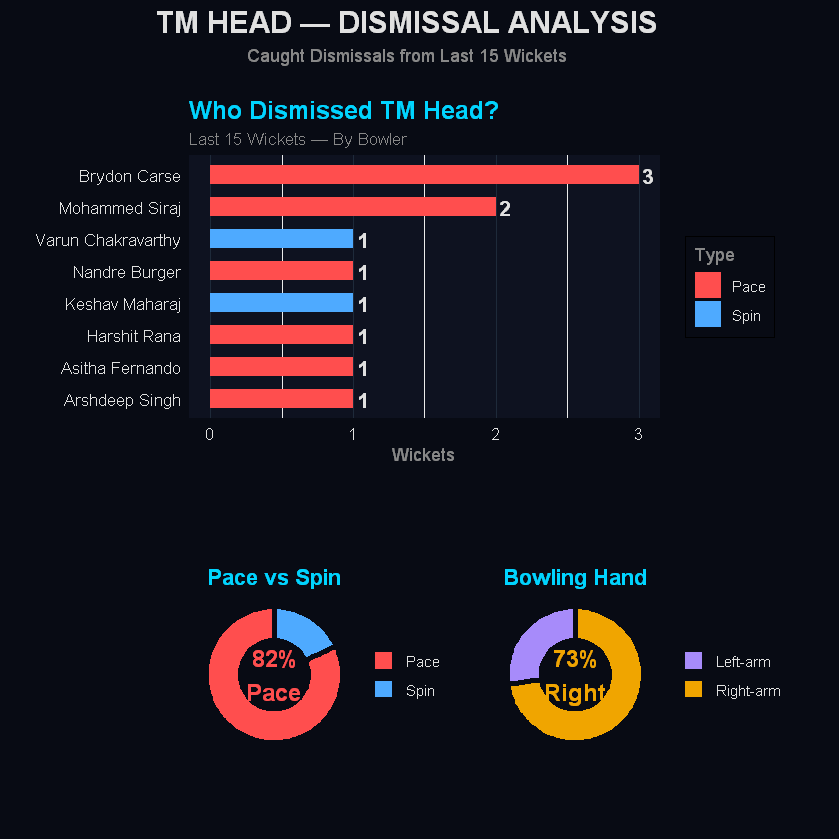

In [11]:
library(ggplot2)
library(patchwork)

# Data
bowler_data <- tibble(
  bowler = c("Brydon Carse", "Mohammed Siraj", "Harshit Rana",
             "Arshdeep Singh", "Nandre Burger", "Asitha Fernando",
             "Keshav Maharaj", "Varun Chakravarthy"),
  wickets = c(3, 2, 1, 1, 1, 1, 1, 1),
  type    = c("Pace", "Pace", "Pace", "Pace", "Pace", "Pace", "Spin", "Spin"),
  hand    = c("Right", "Right", "Right", "Left", "Left", "Right", "Left", "Right")
)

bg      <- "#080b14"
card    <- "#0e1220"
accent  <- "#00d4ff"
pace_c  <- "#ff4e4e"
spin_c  <- "#4eaaff"
text_c  <- "#e0e0e0"
subtext <- "#888888"

# Plot 1 - Bowler bar chart
p1 <- ggplot(bowler_data, aes(x = reorder(bowler, wickets), y = wickets, fill = type)) +
  geom_col(width = 0.6) +
  geom_text(aes(label = wickets), hjust = -0.3, color = text_c, size = 4.5, fontface = "bold") +
  scale_fill_manual(values = c("Pace" = pace_c, "Spin" = spin_c)) +
  coord_flip(clip = "off") +
  labs(title = "Who Dismissed TM Head?", subtitle = "Last 15 Wickets — By Bowler", 
       x = NULL, y = "Wickets", fill = "Type") +
  theme_minimal() +
  theme(
    plot.background  = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = card, color = NA),
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line(color = "#1e2a3a"),
    plot.title    = element_text(color = accent, size = 15, face = "bold"),
    plot.subtitle = element_text(color = subtext, size = 10),
    axis.text     = element_text(color = text_c, size = 10),
    axis.title.x  = element_text(color = subtext),
    legend.background = element_rect(fill = bg),
    legend.text   = element_text(color = text_c),
    legend.title  = element_text(color = subtext),
    plot.margin   = margin(15, 30, 15, 15)
  )

# Plot 2 - Pace vs Spin donut
type_data <- tibble(
  type  = c("Pace", "Spin"),
  n     = c(9, 2),
  frac  = c(9, 2) / 11
)

p2 <- ggplot(type_data, aes(x = 2, y = frac, fill = type)) +
  geom_col(width = 1, color = bg, linewidth = 1.5) +
  coord_polar(theta = "y") +
  xlim(0.5, 2.5) +
  scale_fill_manual(values = c("Pace" = pace_c, "Spin" = spin_c)) +
  annotate("text", x = 0.5, y = 0, label = "82%\nPace", 
           color = pace_c, size = 5, fontface = "bold") +
  labs(title = "Pace vs Spin", fill = NULL) +
  theme_void() +
  theme(
    plot.background = element_rect(fill = bg, color = NA),
    plot.title      = element_text(color = accent, size = 13, face = "bold", hjust = 0.5),
    legend.text     = element_text(color = text_c),
    plot.margin     = margin(15, 15, 15, 15)
  )

# Plot 3 - Right vs Left donut
hand_data <- tibble(
  hand = c("Right-arm", "Left-arm"),
  n    = c(8, 3),
  frac = c(8, 3) / 11
)

p3 <- ggplot(hand_data, aes(x = 2, y = frac, fill = hand)) +
  geom_col(width = 1, color = bg, linewidth = 1.5) +
  coord_polar(theta = "y") +
  xlim(0.5, 2.5) +
  scale_fill_manual(values = c("Right-arm" = "#f0a500", "Left-arm" = "#a78bfa")) +
  annotate("text", x = 0.5, y = 0, label = "73%\nRight", 
           color = "#f0a500", size = 5, fontface = "bold") +
  labs(title = "Bowling Hand", fill = NULL) +
  theme_void() +
  theme(
    plot.background = element_rect(fill = bg, color = NA),
    plot.title      = element_text(color = accent, size = 13, face = "bold", hjust = 0.5),
    legend.text     = element_text(color = text_c),
    plot.margin     = margin(15, 15, 15, 15)
  )

# Combine
final_plot <- p1 / (p2 | p3) +
  plot_annotation(
    title   = "TM HEAD — DISMISSAL ANALYSIS",
    subtitle = "Caught Dismissals from Last 15 Wickets",
    theme = theme(
      plot.background = element_rect(fill = bg, color = NA),
      plot.title      = element_text(color = text_c, size = 18, face = "bold", hjust = 0.5),
      plot.subtitle   = element_text(color = subtext, size = 11, hjust = 0.5)
    )
  )

ggsave("../Output/head_dismissal_analysis.png", final_plot, 
       width = 10, height = 10, dpi = 150, bg = bg)

final_plot

In [10]:
install.packages("patchwork")

Installing package into 'C:/Users/User/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'patchwork' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\User\AppData\Local\Temp\Rtmpc3nOoF\downloaded_packages


In [12]:
head_dismissals <- tibble(
  match_no       = 1:12,
  bowler         = c("Mohammed Siraj", "Harshit Rana", "Arshdeep Singh", 
                     "KA Maharaj", "N Burger", "CV Varun",
                     "JC Archer", "AM Fernando", "BA Carse",
                     "BA Carse", "BA Carse", "MW Forde"),
  delivery_type  = c("Back of length", "Length ball", "Full outswinger",
                     "Flighted spinner", "Full length", "Flighted spinner",
                     "Full length pace", "Short ball", "Back of length",
                     "Short ball", "Short of length", "Short ball"),
  length_zone    = c("Back of length", "Length", "Full",
                     "Full/Flighted", "Full", "Full/Flighted",
                     "Full", "Short", "Back of length",
                     "Short", "Short of length", "Short"),
  fielding_pos   = c("Backward point", "Mid-on", "Deep third",
                     "Long-off", "Mid-on", "Long-off",
                     "Bowler (C&B)", "Deep sq leg", "Cover",
                     "Deep backward sq", "Behind (wk)", "Deep midwicket"),
  bowler_type    = c("Pace", "Pace", "Pace",
                     "Spin", "Pace", "Spin",
                     "Pace", "Pace", "Pace",
                     "Pace", "Pace", "Pace"),
  bowler_hand    = c("Right", "Right", "Left",
                     "Left", "Left", "Right",
                     "Right", "Right", "Right",
                     "Right", "Right", "Right"),
  shot_attempt   = c("Cut/Ramp", "Flick", "Drive/Slash",
                     "Lofted drive", "Lofted drive", "Lofted drive",
                     "Slog", "Pull", "Back-foot drive",
                     "Pull", "Cut", "Pull")
)

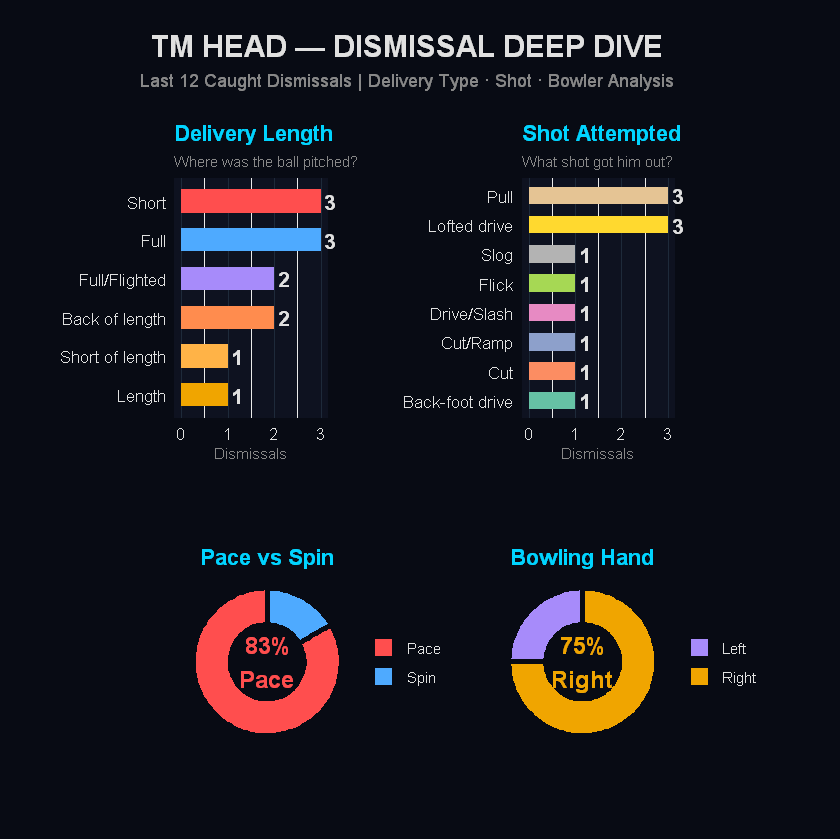

In [13]:
library(ggplot2)
library(patchwork)
library(dplyr)

bg      <- "#080b14"
card    <- "#0e1220"
accent  <- "#00d4ff"
pace_c  <- "#ff4e4e"
spin_c  <- "#4eaaff"
text_c  <- "#e0e0e0"
subtext <- "#888888"
gold    <- "#f0a500"
purple  <- "#a78bfa"

# --- Plot 1: Delivery Length Breakdown ---
length_summary <- head_dismissals %>%
  count(length_zone) %>%
  arrange(desc(n))

p1 <- ggplot(length_summary, aes(x = reorder(length_zone, n), y = n, fill = length_zone)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = n), hjust = -0.3, color = text_c, size = 4.5, fontface = "bold") +
  scale_fill_manual(values = c(
    "Short"          = pace_c,
    "Back of length" = "#ff8c4e",
    "Short of length"= "#ffb347",
    "Length"         = gold,
    "Full"           = spin_c,
    "Full/Flighted"  = "#a78bfa"
  )) +
  coord_flip(clip = "off") +
  labs(title = "Delivery Length", subtitle = "Where was the ball pitched?",
       x = NULL, y = "Dismissals") +
  theme_minimal() +
  theme(
    plot.background   = element_rect(fill = bg, color = NA),
    panel.background  = element_rect(fill = card, color = NA),
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line(color = "#1e2a3a"),
    plot.title    = element_text(color = accent, size = 13, face = "bold"),
    plot.subtitle = element_text(color = subtext, size = 9),
    axis.text     = element_text(color = text_c, size = 10),
    axis.title.x  = element_text(color = subtext, size = 9),
    plot.margin   = margin(15, 30, 15, 15)
  )

# --- Plot 2: Shot Type Breakdown ---
shot_summary <- head_dismissals %>%
  count(shot_attempt) %>%
  arrange(desc(n))

p2 <- ggplot(shot_summary, aes(x = reorder(shot_attempt, n), y = n, fill = shot_attempt)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = n), hjust = -0.3, color = text_c, size = 4.5, fontface = "bold") +
  scale_fill_brewer(palette = "Set2") +
  coord_flip(clip = "off") +
  labs(title = "Shot Attempted", subtitle = "What shot got him out?",
       x = NULL, y = "Dismissals") +
  theme_minimal() +
  theme(
    plot.background   = element_rect(fill = bg, color = NA),
    panel.background  = element_rect(fill = card, color = NA),
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line(color = "#1e2a3a"),
    plot.title    = element_text(color = accent, size = 13, face = "bold"),
    plot.subtitle = element_text(color = subtext, size = 9),
    axis.text     = element_text(color = text_c, size = 10),
    axis.title.x  = element_text(color = subtext, size = 9),
    plot.margin   = margin(15, 30, 15, 15)
  )

# --- Plot 3: Pace vs Spin donut ---
type_data <- head_dismissals %>% count(bowler_type)

p3 <- ggplot(type_data, aes(x = 2, y = n, fill = bowler_type)) +
  geom_col(width = 1, color = bg, linewidth = 1.5) +
  coord_polar(theta = "y") +
  xlim(0.5, 2.5) +
  scale_fill_manual(values = c("Pace" = pace_c, "Spin" = spin_c)) +
  annotate("text", x = 0.5, y = 0, label = "83%\nPace",
           color = pace_c, size = 5, fontface = "bold") +
  labs(title = "Pace vs Spin", fill = NULL) +
  theme_void() +
  theme(
    plot.background = element_rect(fill = bg, color = NA),
    plot.title      = element_text(color = accent, size = 13, face = "bold", hjust = 0.5),
    legend.text     = element_text(color = text_c),
    plot.margin     = margin(15, 15, 15, 15)
  )

# --- Plot 4: Bowling Hand donut ---
hand_data <- head_dismissals %>% count(bowler_hand)

p4 <- ggplot(hand_data, aes(x = 2, y = n, fill = bowler_hand)) +
  geom_col(width = 1, color = bg, linewidth = 1.5) +
  coord_polar(theta = "y") +
  xlim(0.5, 2.5) +
  scale_fill_manual(values = c("Right" = gold, "Left" = purple)) +
  annotate("text", x = 0.5, y = 0, label = "75%\nRight",
           color = gold, size = 5, fontface = "bold") +
  labs(title = "Bowling Hand", fill = NULL) +
  theme_void() +
  theme(
    plot.background = element_rect(fill = bg, color = NA),
    plot.title      = element_text(color = accent, size = 13, face = "bold", hjust = 0.5),
    legend.text     = element_text(color = text_c),
    plot.margin     = margin(15, 15, 15, 15)
  )

# --- Combine ---
final_plot <- (p1 | p2) / (p3 | p4) +
  plot_annotation(
    title    = "TM HEAD — DISMISSAL DEEP DIVE",
    subtitle = "Last 12 Caught Dismissals | Delivery Type · Shot · Bowler Analysis",
    theme = theme(
      plot.background = element_rect(fill = bg, color = NA),
      plot.title      = element_text(color = text_c, size = 18, face = "bold", hjust = 0.5),
      plot.subtitle   = element_text(color = subtext, size = 11, hjust = 0.5),
      plot.margin     = margin(20, 20, 20, 20)
    )
  )

ggsave("../Output/head_dismissal_deepdive.png", final_plot,
       width = 14, height = 10, dpi = 150, bg = bg)

final_plot

In [14]:
library(ggplot2)
library(ggforce)

head_fielding <- tibble(
  match_no     = 1:12,
  bowler       = c("Mohammed Siraj", "Harshit Rana", "Arshdeep Singh",
                   "KA Maharaj", "N Burger", "CV Varun",
                   "JC Archer", "AM Fernando", "BA Carse",
                   "BA Carse", "BA Carse", "MW Forde"),
  fielding_pos = c("Backward Point", "Mid-on", "Deep Third",
                   "Long-off", "Mid-on", "Long-off",
                   "Bowler (C&B)", "Deep Sq Leg", "Cover",
                   "Deep Backward Sq", "Keeper (Behind)", "Deep Midwicket"),
  bowler_type  = c("Pace","Pace","Pace","Spin","Pace","Spin",
                   "Pace","Pace","Pace","Pace","Pace","Pace"),
  # x, y coordinates (center = 0,0, pitch runs vertically)
  x = c( 0.55, -0.25, 0.85, -0.55,  -0.25, -0.55,
          0.00,  -0.80,  0.45, -0.80,   0.05,  -0.65),
  y = c( 0.20,  0.45,  -0.55,  0.75,   0.45,  0.75,
          0.30,  -0.55,  0.35, -0.30,  -0.10,  0.60)
)

ERROR: Error in library(ggforce): there is no package called 'ggforce'


In [15]:
install.packages("ggforce")

Installing package into 'C:/Users/User/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)

also installing the dependencies 'tweenr', 'polyclip'




package 'tweenr' successfully unpacked and MD5 sums checked
package 'polyclip' successfully unpacked and MD5 sums checked
package 'ggforce' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\User\AppData\Local\Temp\Rtmpc3nOoF\downloaded_packages


In [16]:
library(ggplot2)
library(ggforce)

head_fielding <- tibble(
  match_no     = 1:12,
  bowler       = c("Mohammed Siraj", "Harshit Rana", "Arshdeep Singh",
                   "KA Maharaj", "N Burger", "CV Varun",
                   "JC Archer", "AM Fernando", "BA Carse",
                   "BA Carse", "BA Carse", "MW Forde"),
  fielding_pos = c("Backward Point", "Mid-on", "Deep Third",
                   "Long-off", "Mid-on", "Long-off",
                   "Bowler (C&B)", "Deep Sq Leg", "Cover",
                   "Deep Backward Sq", "Keeper (Behind)", "Deep Midwicket"),
  bowler_type  = c("Pace","Pace","Pace","Spin","Pace","Spin",
                   "Pace","Pace","Pace","Pace","Pace","Pace"),
  # x, y coordinates (center = 0,0, pitch runs vertically)
  x = c( 0.55, -0.25, 0.85, -0.55,  -0.25, -0.55,
          0.00,  -0.80,  0.45, -0.80,   0.05,  -0.65),
  y = c( 0.20,  0.45,  -0.55,  0.75,   0.45,  0.75,
          0.30,  -0.55,  0.35, -0.30,  -0.10,  0.60)
)

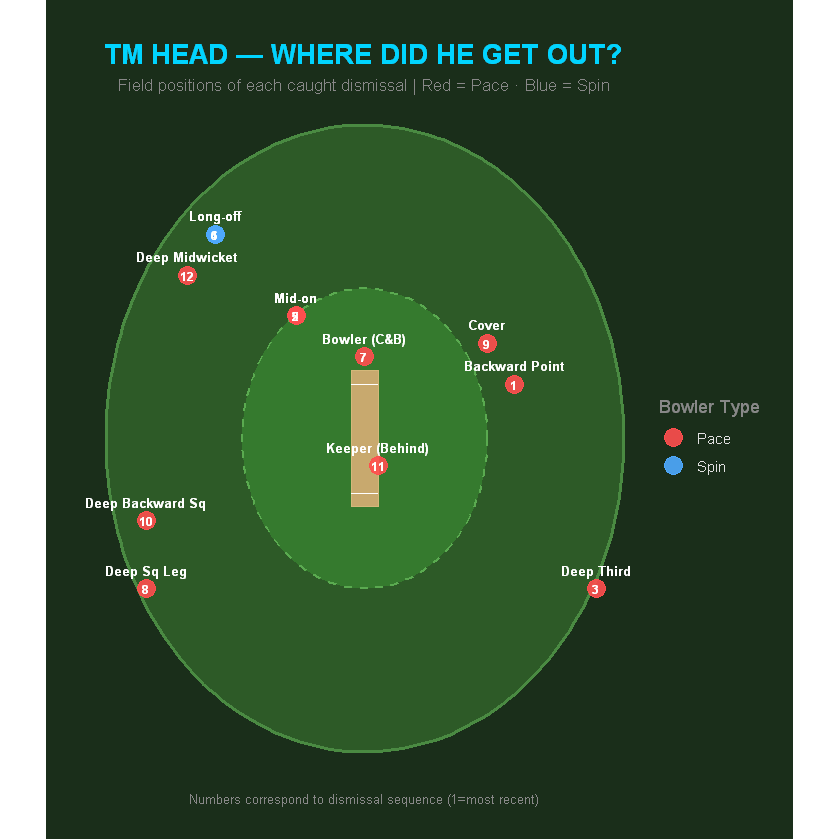

In [17]:
bg     <- "#1a2e1a"  # dark green
text_c <- "#e0e0e0"
accent <- "#00d4ff"
subtext <- "#888888"

# Oval boundary
theta <- seq(0, 2*pi, length.out = 200)
oval  <- tibble(x = 0.95 * cos(theta), y = 1.15 * sin(theta))

# 30-yard circle
inner <- tibble(x = 0.45 * cos(theta), y = 0.55 * sin(theta))

ggplot() +
  # Outfield
  geom_polygon(data = oval, aes(x, y), fill = "#2d5a27", color = "#4a8a42", linewidth = 1) +
  # Infield circle
  geom_polygon(data = inner, aes(x, y), fill = "#357a2e", color = "#5aaa50", linewidth = 0.8, linetype = "dashed") +
  # Pitch
  geom_rect(aes(xmin = -0.05, xmax = 0.05, ymin = -0.25, ymax = 0.25),
            fill = "#c8a96e", color = "#d4b87a") +
  # Crease lines
  geom_segment(aes(x = -0.05, xend = 0.05, y = 0.20, yend = 0.20), color = "white", linewidth = 0.5) +
  geom_segment(aes(x = -0.05, xend = 0.05, y = -0.20, yend = -0.20), color = "white", linewidth = 0.5) +
  # Dismissal points
  geom_point(data = head_fielding, aes(x, y, color = bowler_type),
             size = 5, alpha = 0.9) +
  geom_text(data = head_fielding, aes(x, y, label = fielding_pos),
            color = "white", size = 2.8, fontface = "bold",
            vjust = -1.2, hjust = 0.5) +
  # Bowler labels on points
  geom_text(data = head_fielding, aes(x, y, label = match_no),
            color = "white", size = 2.5, fontface = "bold") +
  scale_color_manual(values = c("Pace" = "#ff4e4e", "Spin" = "#4eaaff")) +
  coord_fixed() +
  labs(
    title    = "TM HEAD — WHERE DID HE GET OUT?",
    subtitle = "Field positions of each caught dismissal | Red = Pace · Blue = Spin",
    color    = "Bowler Type",
    caption  = "Numbers correspond to dismissal sequence (1=most recent)"
  ) +
  theme_void() +
  theme(
    plot.background = element_rect(fill = bg, color = NA),
    plot.title      = element_text(color = accent, size = 16, face = "bold", hjust = 0.5),
    plot.subtitle   = element_text(color = subtext, size = 10, hjust = 0.5),
    plot.caption    = element_text(color = subtext, size = 8, hjust = 0.5),
    legend.text     = element_text(color = text_c),
    legend.title    = element_text(color = subtext),
    plot.margin     = margin(20, 20, 20, 20)
  )

ggsave("../Output/head_field_positions.png", width = 10, height = 11, dpi = 150, bg = bg)

In [20]:
# Check exact Cricsheet names for our squad
aus_squad_search <- c("Short", "Inglis", "Scott", "Peake", "Connolly", 
                      "Labuschagne", "Carey", "Renshaw", "Green")

matches <- df %>%
  filter(batting_team == "Australia") %>%
  distinct(batter) %>%
  filter(grepl(paste(aus_squad_search, collapse = "|"), batter, ignore.case = TRUE))

print(matches)

# A tibble: 10 × 1
   batter       
   <chr>        
 1 AT Carey     
 2 DJM Short    
 3 NJ Carey     
 4 M Labuschagne
 5 C Green      
 6 JP Inglis    
 7 MW Short     
 8 C Connolly   
 9 MT Renshaw   
10 OJ Peake     


In [21]:
df$date <- as.Date(df$date)

aus_last15 <- df %>%
  filter(batting_team == "Australia", batter %in% aus_squad) %>%
  group_by(batter) %>%
  mutate(match_rank = dense_rank(desc(date))) %>%
  filter(match_rank <= 15) %>%
  summarise(
    total_runs  = sum(runs_batter, na.rm = TRUE),
    balls_faced = n(),
    innings     = n_distinct(match_id),
    strike_rate = round(total_runs / balls_faced * 100, 2)
  ) %>%
  arrange(desc(total_runs))

print(aus_last15)

# A tibble: 0 × 5
# ℹ 5 variables: batter <chr>, total_runs <dbl>, balls_faced <int>,
#   innings <int>, strike_rate <dbl>


In [22]:
# Redefine squad
aus_squad <- c("MW Short", "M Labuschagne", "JP Inglis", "C Green", 
               "AT Carey", "MT Renshaw", "C Connolly", "OJ Peake")

# Fix date format
df$date <- as.Date(df$date)

# Last 15 matches per batter
aus_last15 <- df %>%
  filter(batting_team == "Australia", batter %in% aus_squad) %>%
  group_by(batter) %>%
  mutate(match_rank = dense_rank(desc(date))) %>%
  filter(match_rank <= 15) %>%
  summarise(
    total_runs  = sum(runs_batter, na.rm = TRUE),
    balls_faced = n(),
    innings     = n_distinct(match_id),
    strike_rate = round(total_runs / balls_faced * 100, 2)
  ) %>%
  arrange(desc(total_runs))

print(aus_last15)

# A tibble: 8 × 5
  batter        total_runs balls_faced innings strike_rate
  <chr>              <dbl>       <int>   <int>       <dbl>
1 JP Inglis            528         509      15       104. 
2 C Green              515         611      15        84.3
3 AT Carey             461         487      15        94.7
4 MW Short             431         499      15        86.4
5 M Labuschagne        304         404      15        75.2
6 MT Renshaw           211         223       5        94.6
7 C Connolly            94         138       5        68.1
8 OJ Peake              38          48       2        79.2


In [23]:
aus_df %>%
  filter(batter == "JP Inglis", wicket == 1) %>%
  arrange(desc(date)) %>%
  slice_head(n = 15) %>%
  mutate(phase = case_when(
    over <= 9  ~ "Powerplay",
    over <= 39 ~ "Middle",
    TRUE       ~ "Death"
  )) %>%
  select(date, match_id, bowler, dismissal_kind, phase, over, runs_batter)

date,match_id,bowler,dismissal_kind,phase,over,runs_batter
<date>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
2026-06-02,1535646,Arafat Minhas,bowled,Middle,26,0
2026-05-30,1535645,Arafat Minhas,lbw,Middle,13,0
2025-08-22,1478902,L Ngidi,caught,Middle,35,0
2025-08-19,1478901,KA Maharaj,bowled,Middle,12,0
2025-03-04,1466426,RA Jadeja,caught,Middle,26,0
2025-02-14,1469168,DN Wellalage,bowled,Middle,14,0
2024-11-10,1426551,Naseem Shah,caught,Middle,10,0
2024-11-08,1426550,Haris Rauf,caught,Middle,13,0
2024-11-04,1426549,Shaheen Shah Afridi,caught,Middle,19,0


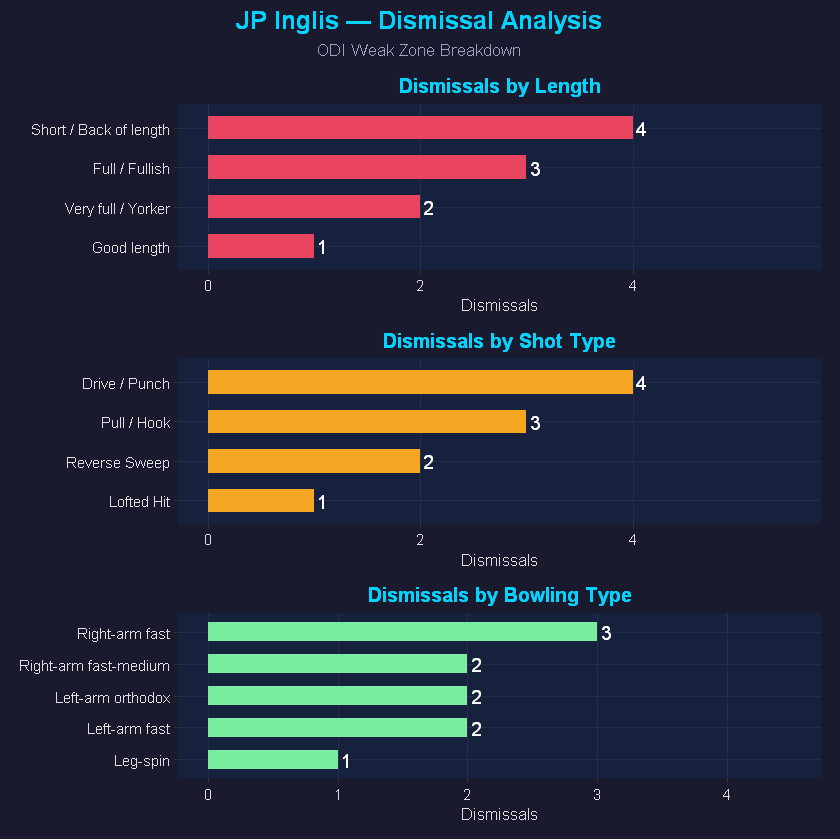

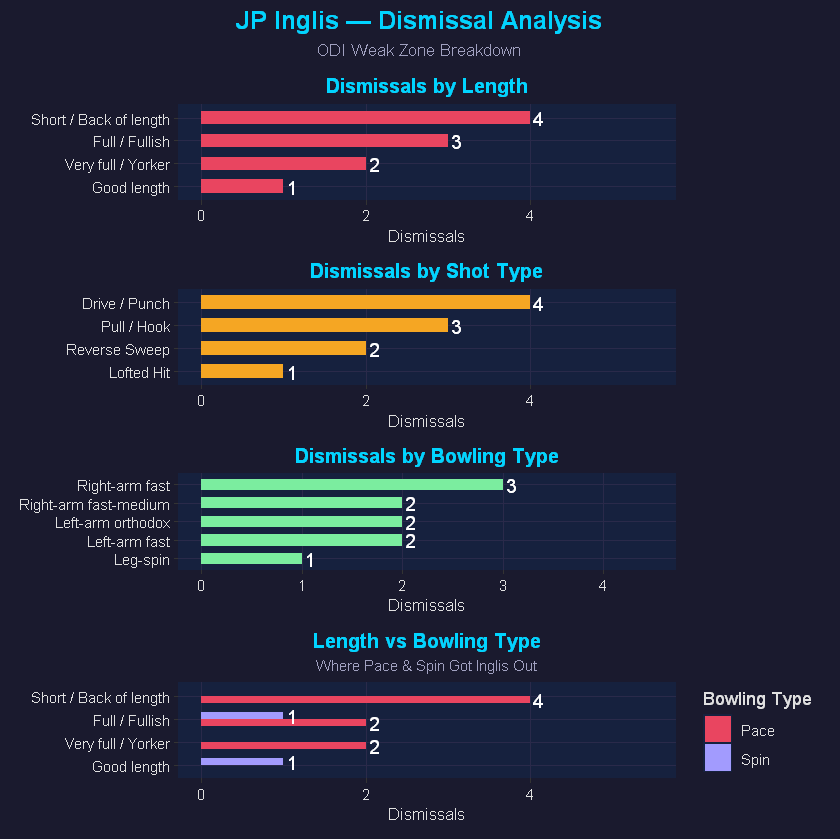

In [28]:
library(ggplot2)
library(patchwork)

# ── Data ──────────────────────────────────────────────────────────────────────
length_data <- data.frame(
  length     = c("Short / Back of length", "Good length", "Full / Fullish", "Very full / Yorker"),
  dismissals = c(4, 1, 3, 2)
)

shot_data <- data.frame(
  shot       = c("Pull / Hook", "Drive / Punch", "Reverse Sweep", "Lofted Hit"),
  dismissals = c(3, 4, 2, 1)
)

bowling_data <- data.frame(
  type       = c("Right-arm fast", "Left-arm fast", "Right-arm fast-medium", "Left-arm orthodox", "Leg-spin"),
  dismissals = c(3, 2, 2, 2, 1)
)

# ── Dark theme ────────────────────────────────────────────────────────────────
dark_theme <- theme(
  plot.background  = element_rect(fill = "#1a1a2e", color = NA),
  panel.background = element_rect(fill = "#16213e", color = NA),
  panel.grid.major = element_line(color = "#2a2a4a"),
  panel.grid.minor = element_blank(),
  axis.text        = element_text(color = "#e0e0e0", size = 9),
  axis.title       = element_text(color = "#e0e0e0", size = 10),
  plot.title       = element_text(color = "#00d4ff", size = 12, face = "bold", hjust = 0.5),
  plot.subtitle    = element_text(color = "#a0a0c0", size = 9, hjust = 0.5)
)

# ── Chart 1: Dismissals by Length ─────────────────────────────────────────────
p1 <- ggplot(length_data, aes(x = reorder(length, dismissals), y = dismissals)) +
  geom_bar(stat = "identity", fill = "#e94560", width = 0.6) +
  geom_text(aes(label = dismissals), hjust = -0.3, color = "#ffffff", size = 4) +
  coord_flip() +
  ylim(0, 5.5) +
  labs(title = "Dismissals by Length", x = NULL, y = "Dismissals") +
  dark_theme

# ── Chart 2: Dismissals by Shot Type ──────────────────────────────────────────
p2 <- ggplot(shot_data, aes(x = reorder(shot, dismissals), y = dismissals)) +
  geom_bar(stat = "identity", fill = "#f5a623", width = 0.6) +
  geom_text(aes(label = dismissals), hjust = -0.3, color = "#ffffff", size = 4) +
  coord_flip() +
  ylim(0, 5.5) +
  labs(title = "Dismissals by Shot Type", x = NULL, y = "Dismissals") +
  dark_theme

# ── Chart 3: Dismissals by Bowling Type ───────────────────────────────────────
p3 <- ggplot(bowling_data, aes(x = reorder(type, dismissals), y = dismissals)) +
  geom_bar(stat = "identity", fill = "#7bed9f", width = 0.6) +
  geom_text(aes(label = dismissals), hjust = -0.3, color = "#ffffff", size = 4) +
  coord_flip() +
  ylim(0, 4.5) +
  labs(title = "Dismissals by Bowling Type", x = NULL, y = "Dismissals") +
  dark_theme

# ── Combine all 3 ─────────────────────────────────────────────────────────────
combined <- (p1 / p2 / p3) +
  plot_annotation(
    title    = "JP Inglis — Dismissal Analysis",
    subtitle = "ODI Weak Zone Breakdown",
    theme    = theme(
      plot.background = element_rect(fill = "#1a1a2e", color = NA),
      plot.title      = element_text(color = "#00d4ff", size = 15, face = "bold", hjust = 0.5),
      plot.subtitle   = element_text(color = "#a0a0c0", size = 10, hjust = 0.5)
    )
  )
# ── Chart 4: Length vs Bowling Type (Pace vs Spin) ────────────────────────────
length_bowling <- data.frame(
  length       = c("Short / Back of length", "Short / Back of length", 
                   "Good length",            "Good length",
                   "Full / Fullish",         "Full / Fullish",
                   "Very full / Yorker",     "Very full / Yorker"),
  bowling_type = c("Pace", "Spin", "Pace", "Spin", "Pace", "Spin", "Pace", "Spin"),
  dismissals   = c(4, 0, 0, 1, 2, 1, 2, 0)
)

p4 <- ggplot(length_bowling, aes(x = reorder(length, dismissals), 
                                  y = dismissals, fill = bowling_type)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.6) +
  geom_text(aes(label = ifelse(dismissals > 0, dismissals, "")), 
            position = position_dodge(width = 0.6), 
            hjust = -0.3, color = "#ffffff", size = 4) +
  scale_fill_manual(values = c("Pace" = "#e94560", "Spin" = "#a29bfe"),
                    name = "Bowling Type") +
  coord_flip() +
  ylim(0, 5.5) +
  labs(title = "Length vs Bowling Type", 
       subtitle = "Where Pace & Spin Got Inglis Out",
       x = NULL, y = "Dismissals") +
  dark_theme +
  theme(legend.background = element_rect(fill = "#1a1a2e"),
        legend.text        = element_text(color = "#e0e0e0"),
        legend.title       = element_text(color = "#e0e0e0"))

# ── Save ───────────────────────────────────────────────────────────────────────
ggsave("../Output/inglis_dismissal_analysis.png", combined, 
       width = 10, height = 12, dpi = 150, bg = "#1a1a2e")

print(combined)
# ── Combine all 4 ─────────────────────────────────────────────────────────────
combined <- (p1 / p2 / p3 / p4) +
  plot_annotation(
    title    = "JP Inglis — Dismissal Analysis",
    subtitle = "ODI Weak Zone Breakdown",
    theme    = theme(
      plot.background = element_rect(fill = "#1a1a2e", color = NA),
      plot.title      = element_text(color = "#00d4ff", size = 15, face = "bold", hjust = 0.5),
      plot.subtitle   = element_text(color = "#a0a0c0", size = 10, hjust = 0.5)
    )
  )

ggsave("../Output/inglis_dismissal_analysis.png", combined, 
       width = 10, height = 16, dpi = 150, bg = "#1a1a2e")

print(combined)

In [26]:
aus_df %>%
  filter(batter == "AT Carey", wicket == 1) %>%
  arrange(desc(date)) %>%
  slice_head(n = 15) %>%
  mutate(phase = case_when(
    over <= 9  ~ "Powerplay",
    over <= 39 ~ "Middle",
    TRUE       ~ "Death"
  )) %>%
  select(date, match_id, bowler, dismissal_kind, phase, over, runs_batter)

date,match_id,bowler,dismissal_kind,phase,over,runs_batter
<date>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
2026-06-02,1535646,Shaheen Shah Afridi,bowled,Powerplay,0,0
2026-05-30,1535645,Abrar Ahmed,caught,Powerplay,6,0
2025-10-25,1478906,Harshit Rana,caught,Middle,33,0
2025-10-23,1478905,Washington Sundar,bowled,Middle,26,0
2025-08-22,1478902,N Burger,caught,Middle,27,0
2025-08-19,1478901,KA Maharaj,lbw,Middle,12,0
2025-03-04,1466426,HH Pandya,run out,Death,47,1
2025-02-22,1466417,BA Carse,caught,Death,41,0
2025-02-12,1459908,KIC Asalanka,caught,Middle,18,0


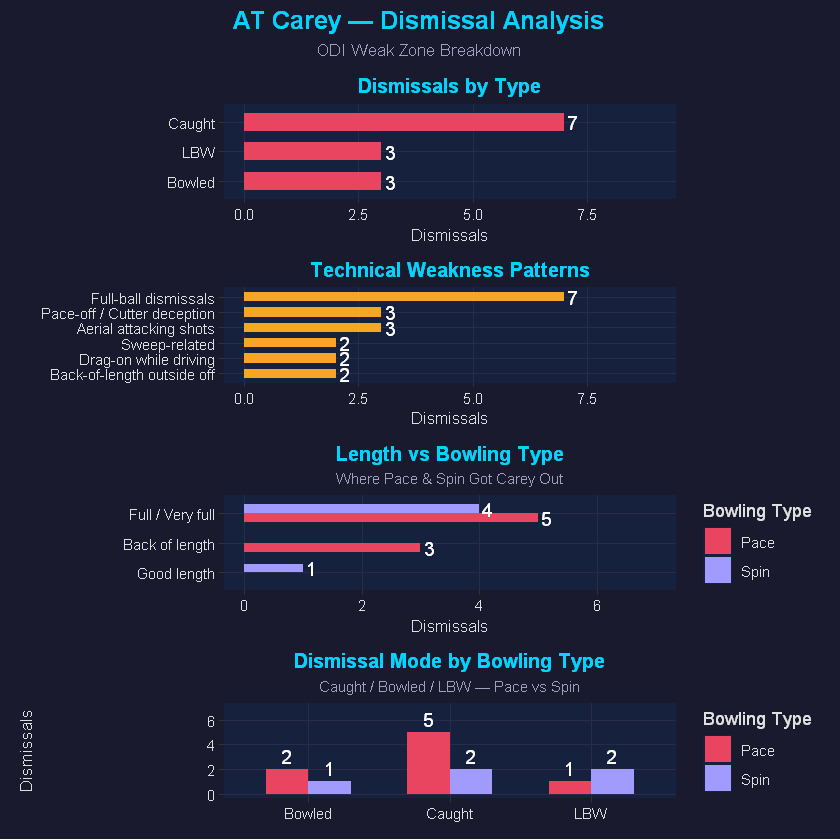

In [29]:
library(ggplot2)
library(patchwork)

# ── Data ──────────────────────────────────────────────────────────────────────
dismissal_type <- data.frame(
  type       = c("Caught", "Bowled", "LBW"),
  dismissals = c(7, 3, 3)
)

technical_pattern <- data.frame(
  pattern    = c("Full-ball dismissals", "Pace-off / Cutter deception",
                 "Aerial attacking shots", "Sweep-related", 
                 "Drag-on while driving", "Back-of-length outside off"),
  dismissals = c(7, 3, 3, 2, 2, 2)
)

length_bowling <- data.frame(
  length       = c("Full / Very full", "Full / Very full",
                   "Back of length",   "Back of length",
                   "Good length",      "Good length"),
  bowling_type = c("Pace", "Spin", "Pace", "Spin", "Pace", "Spin"),
  dismissals   = c(5, 4, 3, 0, 0, 1)
)

mode_bowling <- data.frame(
  mode    = c("Caught", "Caught", "Bowled", "Bowled", "LBW", "LBW"),
  bowling = c("Pace",   "Spin",   "Pace",   "Spin",   "Pace", "Spin"),
  count   = c(5, 2, 2, 1, 1, 2)
)

# ── Dark theme ────────────────────────────────────────────────────────────────
dark_theme <- theme(
  plot.background  = element_rect(fill = "#1a1a2e", color = NA),
  panel.background = element_rect(fill = "#16213e", color = NA),
  panel.grid.major = element_line(color = "#2a2a4a"),
  panel.grid.minor = element_blank(),
  axis.text        = element_text(color = "#e0e0e0", size = 9),
  axis.title       = element_text(color = "#e0e0e0", size = 10),
  plot.title       = element_text(color = "#00d4ff", size = 12, face = "bold", hjust = 0.5),
  plot.subtitle    = element_text(color = "#a0a0c0", size = 9, hjust = 0.5),
  legend.background = element_rect(fill = "#1a1a2e"),
  legend.text       = element_text(color = "#e0e0e0"),
  legend.title      = element_text(color = "#e0e0e0")
)

# ── Chart 1: Dismissals by Type ───────────────────────────────────────────────
p1 <- ggplot(dismissal_type, aes(x = reorder(type, dismissals), y = dismissals)) +
  geom_bar(stat = "identity", fill = "#e94560", width = 0.6) +
  geom_text(aes(label = dismissals), hjust = -0.3, color = "#ffffff", size = 4) +
  coord_flip() +
  ylim(0, 9) +
  labs(title = "Dismissals by Type", x = NULL, y = "Dismissals") +
  dark_theme

# ── Chart 2: Technical Weakness Pattern ───────────────────────────────────────
p2 <- ggplot(technical_pattern, aes(x = reorder(pattern, dismissals), y = dismissals)) +
  geom_bar(stat = "identity", fill = "#f5a623", width = 0.6) +
  geom_text(aes(label = dismissals), hjust = -0.3, color = "#ffffff", size = 4) +
  coord_flip() +
  ylim(0, 9) +
  labs(title = "Technical Weakness Patterns", x = NULL, y = "Dismissals") +
  dark_theme

# ── Chart 3: Length vs Bowling Type ───────────────────────────────────────────
p3 <- ggplot(length_bowling, aes(x = reorder(length, dismissals), 
                                  y = dismissals, fill = bowling_type)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.6) +
  geom_text(aes(label = ifelse(dismissals > 0, dismissals, "")),
            position = position_dodge(width = 0.6),
            hjust = -0.3, color = "#ffffff", size = 4) +
  scale_fill_manual(values = c("Pace" = "#e94560", "Spin" = "#a29bfe"),
                    name = "Bowling Type") +
  coord_flip() +
  ylim(0, 7) +
  labs(title = "Length vs Bowling Type",
       subtitle = "Where Pace & Spin Got Carey Out",
       x = NULL, y = "Dismissals") +
  dark_theme

# ── Chart 4: Dismissal Mode vs Bowling Type ───────────────────────────────────
p4 <- ggplot(mode_bowling, aes(x = mode, y = count, fill = bowling)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.6) +
  geom_text(aes(label = ifelse(count > 0, count, "")),
            position = position_dodge(width = 0.6),
            vjust = -0.4, color = "#ffffff", size = 4) +
  scale_fill_manual(values = c("Pace" = "#e94560", "Spin" = "#a29bfe"),
                    name = "Bowling Type") +
  ylim(0, 7) +
  labs(title = "Dismissal Mode by Bowling Type",
       subtitle = "Caught / Bowled / LBW — Pace vs Spin",
       x = NULL, y = "Dismissals") +
  dark_theme

# ── Combine all 4 ─────────────────────────────────────────────────────────────
combined <- (p1 / p2 / p3 / p4) +
  plot_annotation(
    title    = "AT Carey — Dismissal Analysis",
    subtitle = "ODI Weak Zone Breakdown",
    theme    = theme(
      plot.background = element_rect(fill = "#1a1a2e", color = NA),
      plot.title      = element_text(color = "#00d4ff", size = 15, face = "bold", hjust = 0.5),
      plot.subtitle   = element_text(color = "#a0a0c0", size = 10, hjust = 0.5)
    )
  )

# ── Save ──────────────────────────────────────────────────────────────────────
ggsave("../Output/carey_dismissal_analysis.png", combined,
       width = 10, height = 16, dpi = 150, bg = "#1a1a2e")

print(combined)